# 02 - Modélisation : des paroles à la prédiction (Rap vs Variété Française)

Dans l’EDA, on a observé des différences nettes de style et de vocabulaire entre le Rap et la Variété Française.  
Ici, on passe à la **prédiction** : transformer les paroles en variables numériques (TF‑IDF) puis entraîner des modèles de classification.

Ce notebook :
- compare et teste  les modèles **LinearSVC / LogisticRegression** et aussi des modèles **tree/boosting** (**RandomForest**, **XGBoost**),
- réalise une optimisation des hyperparamètres via **BayesSearchCV** (scikit‑optimize),

> Remarque : si `xgboost` ou `scikit-optimize` ne sont pas installés, installe-les :  
> `pip install xgboost scikit-optimize`

In [1]:
# Imports
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold, GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    f1_score, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings(
    "ignore",
    message="Your stop_words may be inconsistent with your preprocessing",
    category=UserWarning,
)
RANDOM_STATE = 11
np.random.seed(RANDOM_STATE)

## 1) Chargement des données

In [2]:
from lyrics_classification.data import CONSOLIDATED_CSV

df = pd.read_csv(CONSOLIDATED_CSV)
print("Shape:", df.shape)
df.head()

Shape: (2633, 4)


,song,lyrics,auteur,genre
0,"Bad Boys de Marseille, Pt. 2w/ La Fonky Family","(Bad boys) canailles, canailles, les mauvais g...",Akhenaton,Rap
1,Bad Boys de Marseille,"Chaud comme Marseille, on vous met le feu Le ...",Akhenaton,Rap
2,Le Calme Comme Essence,"Le vacarme des humains, parfois me rend patraq...",Akhenaton,Rap
3,La Cosca,"Ma famille est sept fois séculaire, ancienne e...",Akhenaton,Rap
4,Je Ne Suis Pas à Plaindre,C'était un jour de pluie où l'on n'aime pas me...,Akhenaton,Rap


In [3]:
print('\nRépartition des classes :\n', df['genre'].value_counts())


Répartition des classes :
 genre
VF     1718
Rap     915
Name: count, dtype: int64


## 2) Stopwords (NLTK + liste custom)
On construit STOP comme dans l'EDA

In [4]:
from lyrics_classification.text import load_stopwords

STOP = load_stopwords() # Union des stopwords NLTK (français) et de la liste custom du projet.

## 3) Prétraitement léger (dans le vectorizer)
- lowercase,
- normalisation des espaces.

Pour ce faire, la fonction `preprocessor` a été écrite dans text.py.

Le TF‑IDF s’occupe ensuite de la tokenisation et de l’extraction de n‑grams.

In [5]:
from lyrics_classification.text import preprocessor

## 4) Encodage cible + split train/test **par artiste**

Le split n'est pas fait chanson par chanson mais **groupé par artiste** (`StratifiedGroupKFold`) :
aucun artiste ne se retrouve à la fois en train et en test. Sinon le modèle peut apprendre une
"signature d'artiste" (mots récurrents, thèmes propres) plutôt qu'un style de genre, ce qui
gonflerait artificiellement le score de test.

In [6]:
X = df["lyrics"]
groups = df["auteur"]
# Encodage y (Rap=1, VF=0)
y = df["genre"].astype(str).map({"VF": 0, "Rap": 1}).astype(int)

# Split GROUPE par artiste : on prend 1 fold sur 5 (StratifiedGroupKFold) comme test,
# les 4 autres comme train. Aucun artiste n'apparaît des deux côtés.
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups)) # split stratifié par genre

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Artistes train:", sorted(groups_train.unique()))
print("Artistes test :", sorted(groups.iloc[test_idx].unique()))

print("Répartition train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Répartition test :", y_test.value_counts(normalize=True).round(3).to_dict())

Train: (2133,) Test: (500,)
Artistes train: ['Akhenaton', 'Alain Bashung', 'Barbara', 'Booba', 'Charles Aznavour', 'Claude Nougaro', 'Dalida', 'Edith Piaf', 'Francis Cabrel', 'IAM', 'JUL', 'Jacques Brel', 'Joe Dassin', 'La Fouine', 'Leo Ferre', 'MHD', 'Orelsan', 'Renaud', 'Supreme NTM']
Artistes test : ['Diam_s', 'Johnny Hallyday', 'Kaaris', 'Nekfeu', 'Sinik', 'Vald']
Répartition train: {0: 0.657, 1: 0.343}
Répartition test : {0: 0.632, 1: 0.368}


## 5.1) Pipelines modèles (LinearSVC / LogReg / RandomForest / XGBoost)

Avec TfidfVectorizer on crée un objet qui va transformer du texte en vecteurs numériques basés sur TF-IDF :
TF (Term Frequency) : fréquence d’un mot dans un document (ici, une chanson).
IDF (Inverse Document Frequency) : pénalise les mots trop fréquents dans tous les documents (ex : “être”, “avoir”, etc.), car ils discriminent peu.
- `ngram_range=(1,1)` : mots (unigrams)
- `min_df=2` : retire les tokens vus dans <2 documents (réduit le bruit)

In [7]:
vec = TfidfVectorizer(
    preprocessor=preprocessor,
    stop_words=list(STOP),
    ngram_range=(1,1),
    min_df=2
)

pipe_svc = Pipeline([
    ("tfidf", vec),
    ("model", LinearSVC())
])

pipe_lr = Pipeline([
    ("tfidf", vec),
    ("model", LogisticRegression(max_iter=3000))
])

pipe_rf = Pipeline([
    ("tfidf", vec),
    ("model", RandomForestClassifier(
        n_estimators=500,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        class_weight="balanced" # gestion du déséquilibre
    ))
])

# XGBoost : poids de classe (gestion du déséquilibre)
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)

pipe_xgb = Pipeline([
    ("tfidf", vec),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight
    ))
])

models = {
    "LinearSVC": pipe_svc,
    "LogReg": pipe_lr,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb
}


## 5.2) BayesSearchCV - optimisation sur le score F1 macro

On optimise **F1 macro** (robuste au déséquilibre).
La cross-validation interne utilise aussi `StratifiedGroupKFold` (groupée par artiste) afin de rester
cohérente avec le split train/test et d'éviter toute fuite d'artiste pendant le tuning.
On rapportera aussi **F1 (classe Rap)** sur le test final.

In [8]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_spaces = {
    "LinearSVC": {
        "tfidf__min_df": Integer(1, 5),
        "model__C": Real(1e-2, 50, prior="log-uniform"),
    },
    "LogReg": {
        "tfidf__min_df": Integer(1, 5),
        "model__C": Real(1e-2, 50, prior="log-uniform"),
        "model__class_weight": Categorical([None, "balanced"]),
    },
    "RandomForest": {
        "tfidf__min_df": Integer(1, 5),
        "model__n_estimators": Integer(50, 200),
        "model__max_depth": Integer(5, 40),
        "model__min_samples_split": Integer(2, 20),
        "model__min_samples_leaf": Integer(1, 10),
        "model__max_features": Categorical(["sqrt", "log2", None]),
    },
    "XGBoost": {
        "tfidf__min_df": Integer(1, 5),
        "model__n_estimators": Integer(50, 200),
        "model__max_depth": Integer(3, 10),
        "model__learning_rate": Real(1e-2, 0.3, prior="log-uniform"),
        "model__subsample": Real(0.6, 1.0),
    }
}

bayes_searches = {}
for name, estimator in models.items():
    bayes_searches[name] = BayesSearchCV(
        estimator=estimator,
        search_spaces=search_spaces[name],
        n_iter=10,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        return_train_score=True,
        verbose=0
    )

bayes_searches.keys()

dict_keys(['LinearSVC', 'LogReg', 'RandomForest', 'XGBoost'])

## 5.3) Exécuter les recherches et résultats

In [9]:
all_rows = []

for algo, search in bayes_searches.items():
    print(f"=== BayesSearchCV: {algo} ===")
    search.fit(X_train, y_train, groups=groups_train)
    print("Best CV F1_macro:", round(search.best_score_, 4))
    print("Best Params:", search.best_params_)

    cv_res = pd.DataFrame(search.cv_results_)
    cv_res["algo"] = algo
    keep = ["algo", "params", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score"]
    all_rows.append(cv_res[keep])

df_res = pd.concat(all_rows, ignore_index=True)
df_res.sort_values("mean_test_score", ascending=False).head(10)

=== BayesSearchCV: LinearSVC ===
Best CV F1_macro: 0.8731
Best Params: OrderedDict({'model__C': 1.1046121158601525, 'tfidf__min_df': 4})
=== BayesSearchCV: LogReg ===
Best CV F1_macro: 0.875
Best Params: OrderedDict({'model__C': 38.92479670047378, 'model__class_weight': 'balanced', 'tfidf__min_df': 3})
=== BayesSearchCV: RandomForest ===
Best CV F1_macro: 0.9198
Best Params: OrderedDict({'model__max_depth': 29, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 7, 'model__n_estimators': 178, 'tfidf__min_df': 4})
=== BayesSearchCV: XGBoost ===
Best CV F1_macro: 0.8961
Best Params: OrderedDict({'model__learning_rate': 0.2714540418308988, 'model__max_depth': 9, 'model__n_estimators': 134, 'model__subsample': 0.7638183110468141, 'tfidf__min_df': 4})


,algo,params,mean_test_score,std_test_score,mean_train_score,std_train_score
22,RandomForest,"{'model__max_depth': 29, 'model__max_features'...",0.919816,0.042314,0.977415,0.003279
25,RandomForest,"{'model__max_depth': 32, 'model__max_features'...",0.917928,0.047374,0.978365,0.002800
26,RandomForest,"{'model__max_depth': 23, 'model__max_features'...",0.917816,0.048489,0.983022,0.002740
20,RandomForest,"{'model__max_depth': 26, 'model__max_features'...",0.914019,0.049380,0.988865,0.003656
21,RandomForest,"{'model__max_depth': 28, 'model__max_features'...",0.910830,0.052066,0.967527,0.007204
23,RandomForest,"{'model__max_depth': 12, 'model__max_features'...",0.909902,0.048861,0.969373,0.002431
24,RandomForest,"{'model__max_depth': 30, 'model__max_features'...",0.907918,0.065721,0.963386,0.008967
39,XGBoost,"{'model__learning_rate': 0.2714540418308988, '...",0.896050,0.037625,0.999480,0.000262
34,XGBoost,"{'model__learning_rate': 0.10907669832175719, ...",0.892952,0.036889,0.998826,0.000261
35,XGBoost,"{'model__learning_rate': 0.132757480359376, 'm...",0.891698,0.044504,0.996243,0.001307


## 5.4) Sélection du meilleur candidat

In [10]:
scorer = "f1_macro"

index_best = df_res.sort_values(
    ["mean_test_score", "std_test_score", "mean_train_score", "std_train_score"],
    ascending=[False, True, False, True]
).index[0]

best_algo = df_res.loc[index_best, "algo"]
best_params = df_res.loc[index_best, "params"]

print(" Best algo  :", best_algo)
print(" Best params:", best_params)
print(" Best CV mean/std:", df_res.loc[index_best, ["mean_test_score","std_test_score"]].to_dict())


 Best algo  : RandomForest
 Best params: OrderedDict({'model__max_depth': 29, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 7, 'model__n_estimators': 178, 'tfidf__min_df': 4})
 Best CV mean/std: {'mean_test_score': 0.9198164066507891, 'std_test_score': 0.042313523735421674}


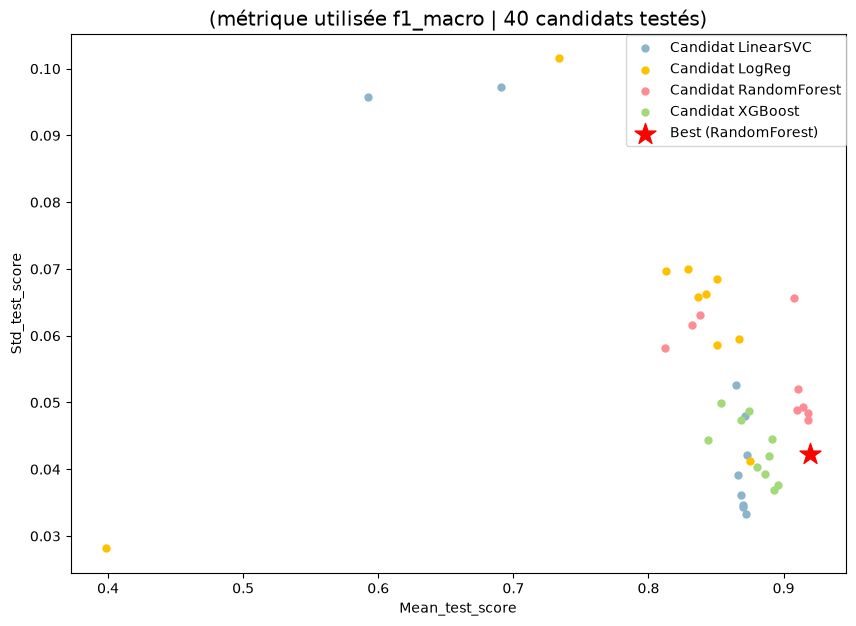

RandomForest OrderedDict({'model__max_depth': 29, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 7, 'model__n_estimators': 178, 'tfidf__min_df': 4})


In [11]:
fig = plt.figure(figsize=(10,7))
color_list = ["#8CB4CA", "#FFC000",  "#FF8B94", "#A3D977"]

for cand_algo, col in zip(df_res['algo'].unique().tolist(), color_list):
    plt.scatter(
        df_res[df_res["algo"]==cand_algo]['mean_test_score'], df_res[df_res["algo"]==cand_algo]['std_test_score'],
        color=col, s=25, label="Candidat "+ cand_algo
    )
plt.scatter(
    df_res.loc[index_best,'mean_test_score'], df_res.loc[index_best,'std_test_score'],
    color='red', marker='*', s=250, label="Best ("+str(df_res.loc[index_best]["algo"])+')'
)
plt.xlabel('Mean_test_score')
plt.ylabel('Std_test_score')
plt.title(f'(métrique utilisée {scorer} | {df_res.shape[0]} candidats testés)',size='x-large')
plt.legend(bbox_to_anchor=(1.01, 1.01))
plt.show()

print(df_res.loc[index_best,'algo'], df_res.loc[index_best,'params'])

## 6.1) Évaluation finale sur le TEST (F1 macro + F1 Rap) + confusion matrix

In [12]:
best_search = bayes_searches[best_algo]
best_estimator = best_search.best_estimator_

best_estimator.fit(X_train, y_train)
y_pred = best_estimator.predict(X_test)

print("F1 macro (test):", round(f1_score(y_test, y_pred, average="macro"), 4))
print("F1 Rap   (test):", round(f1_score(y_test, y_pred, pos_label=1), 4))
print()
print(classification_report(y_test, y_pred, target_names=["VF","Rap"]))

F1 macro (test): 0.965
F1 Rap   (test): 0.9548

              precision    recall  f1-score   support

          VF       0.95      1.00      0.98       316
         Rap       0.99      0.92      0.95       184

    accuracy                           0.97       500
   macro avg       0.97      0.96      0.97       500
weighted avg       0.97      0.97      0.97       500



## 6.2) Matrice de confusion (test)

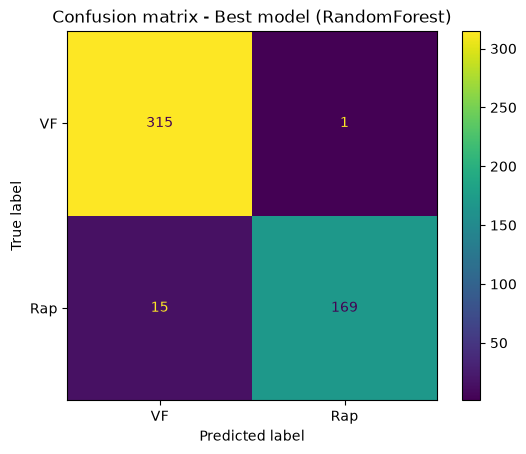

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["VF","Rap"])
disp.plot(values_format="d")
plt.title(f"Confusion matrix - Best model ({best_algo})")
plt.show()

## 7) Analyse d’erreurs (exemples)

On extrait quelques faux positifs / faux négatifs pour comprendre les cas difficiles. 
(5 exemple)

In [14]:
test_df = pd.DataFrame({
    "lyrics": X_test.values,
    "y_true": np.array(y_test),
    "y_pred": y_pred
})

fp = test_df[(test_df.y_true==0) & (test_df.y_pred==1)]  # VF prédite Rap
fn = test_df[(test_df.y_true==1) & (test_df.y_pred==0)]  # Rap prédit VF

print("Faux positifs (VF→Rap):", len(fp))
print("Faux négatifs (Rap→VF):", len(fn))

def show_examples(df_examples, n=5, title=""):
    print("\n" + title)
    for _, row in df_examples.head(n).iterrows():
        snippet = row["lyrics"][:450].replace("\n", " ")
        print("-" * 90)
        print(snippet, "...")

show_examples(fp, n=5, title="Exemples VF prédits Rap (faux positifs)")
show_examples(fn, n=5, title="Exemples Rap prédits VF (faux négatifs)")

Faux positifs (VF→Rap): 1
Faux négatifs (Rap→VF): 15

Exemples VF prédits Rap (faux positifs)
------------------------------------------------------------------------------------------
Mes baskets blanches, mes locks, l'encre a coulé comme le Trois Rivières   Au fond des blocs, enfants des îles, fils d'une classe ouvrière   L'idole des jeunes, Doc restera le même de Porte de la Chapelle, aux ondes hertziennes     À l'heure où le monde se bouscule   Je repasse ma vie à l'envers   J'en ai fait des rêves, des calculs   J'ai jamais voulu vraiment me laisser faire (jamais, jamais, jamais, jamais)    Et le temps passe, non je ne regr ...

Exemples Rap prédits VF (faux négatifs)
------------------------------------------------------------------------------------------
J'ai 20 ans  J'ai la vie dont tout le monde rêve, sous le feu des projecteurs   Toujours le sourire aux lèvres    J'ai 20 ans  Dans un monde où l'amour crève   Je m'accroche à mes valeurs sans jamais demander de trêve  J'aurai t

## 13) Conclusion

L'objectif de ce projet était de déterminer s'il est possible de **prédire le genre** d'une chanson (**Rap vs Variété Française**) uniquement à partir de ses **paroles**.
Les résultats montrent que le texte contient un **signal fortement discriminant**, même en évaluant sur des **artistes jamais vus à l'entraînement**.

### Méthodologie corrigée
- Le split train/test et la cross-validation interne sont **groupés par artiste** (`StratifiedGroupKFold`) : aucun artiste n'apparaît à la fois en train et en test. Auparavant le split se faisait chanson par chanson, ce qui laissait le modèle apprendre une "signature d'artiste" plutôt qu'un style de genre. Un score très stable mais artificiellement optimiste.

### Résultats clés (split par artiste + stopwords corrigés)
- Meilleur modèle sélectionné via CV (métrique principale : F1 macro, moyenne sur 5 folds `StratifiedGroupKFold`) : **RandomForest**
  - **F1 macro (CV) : 0.9198 ± 0.0423**
- Performances sur le jeu de test (6 artistes jamais vus à l'entraînement : Diam's, Johnny Hallyday, Kaaris, Nekfeu, Sinik, Vald) :
  - **F1 macro : 0.965**
  - **F1 (Rap) : 0.9548**
  - **Accuracy : 0.97**

**Historique des corrections :**
| Version | F1 macro (test) | F1 macro CV (± std) |
|---|---|---|
| Split par chanson (fuite d'artiste) | 0.9632 | 0.9486 ± 0.0076 |
| Split par artiste (stopwords buggés) | 0.9606 | 0.9203 ± 0.0551 |
| Split par artiste + stopwords corrigés | **0.965** | **0.9198 ± 0.0423** |

Le score de test final reste stable et même légèrement meilleur après correction complète ; l'écart-type de CV redescend un peu (mais reste bien supérieur à la version avec fuite), signe d'une évaluation plus propre.

### Limites (mises à jour)
- **Diversité d'artistes limitée au test** : avec seulement ~13 artistes par genre, un split unique par groupe peut être déséquilibré. Ici le test final ne contient qu'**un seul artiste VF** (Johnny Hallyday) contre 5 artistes Rap. Le score CV (moyenné sur 5 découpages différents) est donc une estimation plus fiable de la généralisation que le score sur ce seul split de test.
- **Biais de longueur** : toujours présent, les paroles de Rap restant en moyenne plus longues.
- **Donnée source vide détectée** : `data/chansons/VF/Georges Brassens.csv` existe mais contient **0 ligne** - un échec de collecte à la source (scraping), pas un bug du pipeline de chargement. Résultat : cet artiste est absent de `data_song.csv`.

### Pistes d'amélioration
- ~~Mettre en place une validation par artiste~~ fait (`StratifiedGroupKFold`).
- Tester des représentations complémentaires (ex. **char n-grams**) ou des modèles plus récents (transformers type CamemBERT). (notebook 03)